In [2]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [2]:
# 加载预训练模型
model = models.resnet34(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0')
model = model.to(device)

# 冻结前8个层
for param in model.conv1.parameters():
    param.requires_grad = False

for param in model.bn1.parameters():
    param.requires_grad = False

for param in model.layer1.parameters():
    param.requires_grad = False

# for param in model.layer2.parameters():
#     param.requires_grad = False

# for param in model.layer3.parameters():
#     param.requires_grad = False

# for param in model.layer4.parameters():
#     param.requires_grad = False

# for param in model.avgpool.parameters():
#     param.requires_grad = False

# for param in model.fc.parameters():
#     param.requires_grad = False

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
#             print(phase,'epoch',":",epoch,'num_imputs',inputs.size())
#             tensor = inputs[0].to(torch.float32).cpu()
#             print(labels[0])
#             # 将张量转换为图像并显示
#             plt.imshow(tensor.permute(1, 2, 0))
#             plt.show()
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_R34.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.4318 Acc: 0.3023
epoch: 0, val Loss: 1.3170 Acc: 0.3829
epoch: 1, train Loss: 0.8680 Acc: 0.7074
epoch: 1, val Loss: 1.0929 Acc: 0.4820
epoch: 2, train Loss: 0.4982 Acc: 0.9050
epoch: 2, val Loss: 0.9405 Acc: 0.6216
epoch: 3, train Loss: 0.3236 Acc: 0.9380
epoch: 3, val Loss: 0.7740 Acc: 0.6577
epoch: 4, train Loss: 0.2178 Acc: 0.9709
epoch: 4, val Loss: 0.5126 Acc: 0.8108
epoch: 5, train Loss: 0.1563 Acc: 0.9903
epoch: 5, val Loss: 0.3438 Acc: 0.8919
epoch: 6, train Loss: 0.1042 Acc: 0.9961
epoch: 6, val Loss: 0.2520 Acc: 0.9189
epoch: 7, train Loss: 0.0964 Acc: 0.9942
epoch: 7, val Loss: 0.2695 Acc: 0.9054
epoch: 8, train Loss: 0.0776 Acc: 0.9961
epoch: 8, val Loss: 0.1967 Acc: 0.9369
epoch: 9, train Loss: 0.0515 Acc: 0.9981
epoch: 9, val Loss: 0.1814 Acc: 0.9414
epoch: 10, train Loss: 0.0518 Acc: 0.9961
epoch: 10, val Loss: 0.1865 Acc: 0.9324
epoch: 11, train Loss: 0.0441 Acc: 0.9981
epoch: 11, val Loss: 0.2275 Acc: 0.9054
epoch: 12, train Loss: 0.0603 Acc: 0

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

453.2699053287506


In [4]:
torch.save(model.state_dict(), 'ResNet34.pth')

In [5]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split
start_time = time.time()
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)
# 创建一个与预训练ResNet-34模型结构相同的模型
model = models.resnet34()
# 替换最后一层为新的线性层
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

# 将模型移动到CUDA设备上
device = torch.device('cuda:0')
model = model.to(device)
# 加载之前保存的模型参数
model.load_state_dict(torch.load('ResNet34.pth'))
for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([0, 3, 0, 2, 3, 3, 0, 1, 0, 1, 3, 2, 1, 3, 0, 0, 2, 1, 2, 2, 0, 1, 3, 0,
        2, 3, 0, 1, 3, 0, 1, 1, 2, 2, 1, 0, 0, 3, 2, 3, 3, 0, 2, 1, 0, 2, 3, 2,
        3, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 1, 2, 0, 0, 0], device='cuda:0') tensor([0, 3, 0, 2, 3, 3, 0, 1, 0, 1, 3, 2, 3, 3, 0, 0, 2, 1, 2, 2, 0, 1, 3, 0,
        2, 3, 0, 3, 3, 0, 1, 3, 2, 2, 1, 0, 3, 3, 2, 3, 1, 0, 2, 1, 0, 2, 3, 2,
        3, 1, 2, 0, 0, 2, 1, 2, 3, 2, 1, 1, 2, 0, 0, 0], device='cuda:0')
0.06036263331770897


In [6]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 14
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('ResNet34_con.png', dpi=300)
    plt.tight_layout()

In [7]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[18  0  0  2]
 [ 0 11  0  3]
 [ 0  0 17  0]
 [ 0  1  0 12]]


Normalized confusion matrix
[[0.9        0.         0.         0.1       ]
 [0.         0.78571429 0.         0.21428571]
 [0.         0.         1.         0.        ]
 [0.         0.07692308 0.         0.92307692]]


<ipython-input-6-2d2bef8b36ce>:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


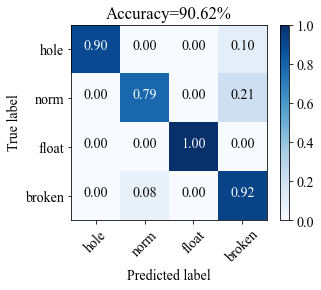

In [8]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)